<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [26]:
x,y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [27]:
x

array([[ 0.59715272,  0.97585909,  0.98684267, -1.78908235, -1.89453055],
       [ 0.33659739,  0.3373409 , -2.35115538, -0.10235123,  0.26656148],
       [-1.24496909,  0.7848554 ,  1.77564851, -0.29954129,  1.32745652],
       [-1.87874775,  0.23967477,  1.03295542, -0.57560855,  1.67985688],
       [ 0.23127239, -0.60164952, -0.37658699,  0.47988055,  0.32735534],
       [-0.43348337,  1.16779424,  0.32193162, -0.26389168,  0.89591851],
       [ 2.69028188, -0.28109489,  2.14598757,  0.68809702, -0.93479891],
       [-0.18745389,  0.25612897,  1.31883856,  0.09307428,  0.5629136 ],
       [-0.4924416 ,  0.48288361, -2.27027004,  0.06173706, -1.27559295],
       [-0.39910798,  0.2955651 , -0.23901844, -0.08426949,  0.82293618],
       [-1.96550182,  1.28821556, -2.5372789 ,  0.23291116, -1.68988487],
       [-0.11604093,  0.28099931,  0.4098845 ,  0.90100163, -1.89120053],
       [ 1.21099803,  2.22020157,  0.22731969,  0.17355315, -1.47940706],
       [-0.73755572, -1.60681192,  0.9

In [28]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.597153,0.975859,0.986843,-1.789082,-1.894531,0
1,0.336597,0.337341,-2.351155,-0.102351,0.266561,0
2,-1.244969,0.784855,1.775649,-0.299541,1.327457,1
3,-1.878748,0.239675,1.032955,-0.575609,1.679857,1
4,0.231272,-0.601650,-0.376587,0.479881,0.327355,1


In [29]:
# function with row sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [30]:
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [31]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [32]:
df1 =sample_rows(df,0.1)

In [33]:
df2 = sample_rows(df,0.1)

In [34]:
df3 = sample_rows(df,0.1)

In [35]:
df3.shape

(10, 6)

In [36]:
df1.shape

(10, 6)

In [37]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [38]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [39]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[0] <= -0.102\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.4, 0.5, 'x[4] <= -0.925\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

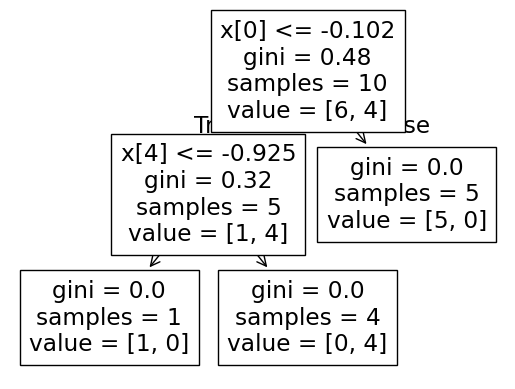

In [40]:
plot_tree(clf1)

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.11\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.4, 0.5, 'x[1] <= 0.382\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

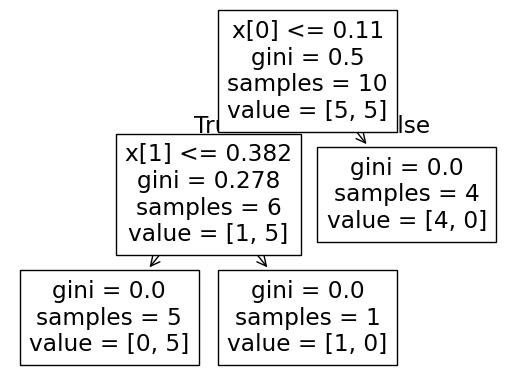

In [41]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.056\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.4, 0.5, 'x[1] <= 1.133\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

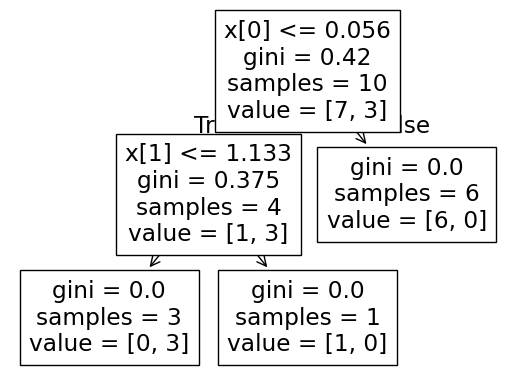

In [42]:
plot_tree(clf3)

In [43]:
clf1.predict(np.array([0.667904	,0.647694	,-0.620770	,-1.335253	,0.224698]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [44]:
clf2.predict(np.array([0.667904	,0.647694	,-0.620770	,-1.335253	,0.224698]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [45]:
clf3.predict(np.array([0.667904	,0.647694	,-0.620770	,-1.335253	,0.224698]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [46]:
df1 = sample_features(df,0.8)
df2 = sample_features(df,0.8)
df3 = sample_features(df,0.8)

/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [50]:
sample_features(df,0.8)

/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col3,col2,col4,col1,target
0,0.986843,0.975859,-1.789082,0.597153,0
1,-2.351155,0.337341,-0.102351,0.336597,0
2,1.775649,0.784855,-0.299541,-1.244969,1
3,1.032955,0.239675,-0.575609,-1.878748,1
4,-0.376587,-0.601650,0.479881,0.231272,1
...,...,...,...,...,...
95,0.589035,0.585426,0.761567,0.243356,1
96,-1.217360,-1.876809,-0.156882,0.875575,1
97,1.726166,-0.113391,1.013292,1.772701,0
98,2.653822,1.783945,0.829421,-0.794419,0


In [49]:
df1.shape

(100, 5)

In [59]:
df1.iloc[:,0:4]

,col3,col4,col2,col5
0,0.986843,-1.789082,0.975859,-1.894531
1,-2.351155,-0.102351,0.337341,0.266561
2,1.775649,-0.299541,0.784855,1.327457
3,1.032955,-0.575609,0.239675,1.679857
4,-0.376587,0.479881,-0.601650,0.327355
...,...,...,...,...
95,0.589035,0.761567,0.585426,1.099256
96,-1.217360,-0.156882,-1.876809,2.087190
97,1.726166,1.013292,-0.113391,-0.818782
98,2.653822,0.829421,1.783945,0.111896


In [60]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.9545454545454546, 'x[3] <= 0.166\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3333333333333333, 0.8636363636363636, 'x[2] <= 0.3\ngini = 0.278\nsamples = 48\nvalue = [40, 8]'),
 Text(0.41666666666666663, 0.9090909090909092, 'True  '),
 Text(0.25, 0.7727272727272727, 'x[0] <= 1.281\ngini = 0.49\nsamples = 14\nvalue = [6, 8]'),
 Text(0.16666666666666666, 0.6818181818181818, 'x[0] <= -1.109\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.08333333333333333, 0.5909090909090909, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.5909090909090909, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.3333333333333333, 0.6818181818181818, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.4166666666666667, 0.7727272727272727, 'gini = 0.0\nsamples = 34\nvalue = [34, 0]'),
 Text(0.6666666666666666, 0.8636363636363636, 'x[1] <= 2.152\ngini = 0.311\nsamples = 52\nvalue = [10, 42]'),
 Text(0.5833333333333333, 0.9090909090909092, '  False'),
 Text(0.58333333333333

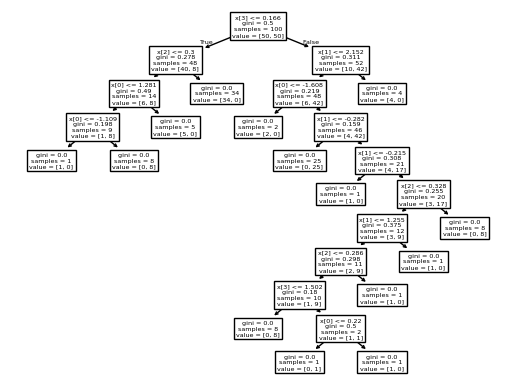

In [61]:
plot_tree(clf1)

[Text(0.5, 0.9545454545454546, 'x[0] <= 0.166\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3333333333333333, 0.8636363636363636, 'x[1] <= 0.3\ngini = 0.278\nsamples = 48\nvalue = [40, 8]'),
 Text(0.41666666666666663, 0.9090909090909092, 'True  '),
 Text(0.25, 0.7727272727272727, 'x[3] <= 1.281\ngini = 0.49\nsamples = 14\nvalue = [6, 8]'),
 Text(0.16666666666666666, 0.6818181818181818, 'x[3] <= -1.109\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.08333333333333333, 0.5909090909090909, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.5909090909090909, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.3333333333333333, 0.6818181818181818, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.4166666666666667, 0.7727272727272727, 'gini = 0.0\nsamples = 34\nvalue = [34, 0]'),
 Text(0.6666666666666666, 0.8636363636363636, 'x[2] <= 2.152\ngini = 0.311\nsamples = 52\nvalue = [10, 42]'),
 Text(0.5833333333333333, 0.9090909090909092, '  False'),
 Text(0.58333333333333

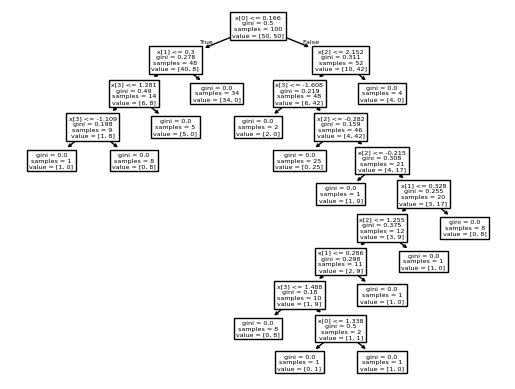

In [62]:
plot_tree(clf2)

[Text(0.4166666666666667, 0.9375, 'x[0] <= -0.138\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.8125, 'x[3] <= 0.626\ngini = 0.245\nsamples = 42\nvalue = [6, 36]'),
 Text(0.2916666666666667, 0.875, 'True  '),
 Text(0.08333333333333333, 0.6875, 'gini = 0.0\nsamples = 35\nvalue = [0, 35]'),
 Text(0.25, 0.6875, 'x[2] <= -0.809\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.16666666666666666, 0.5625, 'x[0] <= -0.7\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.08333333333333333, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.6666666666666666, 0.8125, 'x[0] <= 1.419\ngini = 0.366\nsamples = 58\nvalue = [44, 14]'),
 Text(0.5416666666666666, 0.875, '  False'),
 Text(0.5833333333333334, 0.6875, 'x[1] <= 1.801\ngini = 0.45\nsamples = 41\nvalue = [27.0, 14.0]'),
 Text(0.5, 0.5625, 'x[0] <= 0.212\ngini

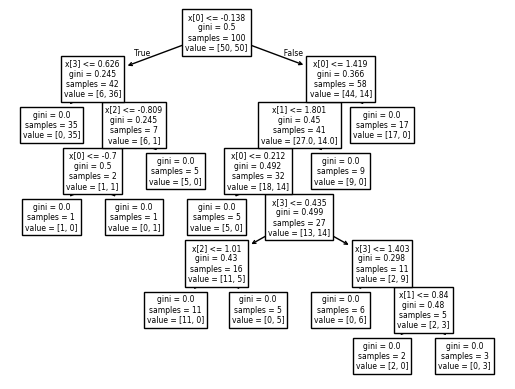

In [63]:
plot_tree(clf3)

In [65]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col4', 'col2', 'col5', 'target'], dtype='object')
Index(['col5', 'col2', 'col4', 'col3', 'target'], dtype='object')
Index(['col2', 'col1', 'col3', 'col4', 'target'], dtype='object')


In [66]:
df3

,col2,col1,col3,col4,target
0,0.975859,0.597153,0.986843,-1.789082,0
1,0.337341,0.336597,-2.351155,-0.102351,0
2,0.784855,-1.244969,1.775649,-0.299541,1
3,0.239675,-1.878748,1.032955,-0.575609,1
4,-0.601650,0.231272,-0.376587,0.479881,1
...,...,...,...,...,...
95,0.585426,0.243356,0.589035,0.761567,1
96,-1.876809,0.875575,-1.217360,-0.156882,1
97,-0.113391,1.772701,1.726166,1.013292,0
98,1.783945,-0.794419,2.653822,0.829421,0


In [71]:
print(clf1.predict(np.array([0.784855,	-1.244969,	1.775649,	-0.299541]).reshape(1,4)))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [72]:
print(clf2.predict(np.array([0.784855,	-1.244969,	1.775649,	-0.299541]).reshape(1,4)))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [73]:
print(clf3.predict(np.array([0.784855,	-1.244969,	1.775649,	-0.299541]).reshape(1,4)))

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [74]:
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [75]:
df1.shape

(50, 3)

In [76]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [77]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_4772/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [78]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col3', 'target'], dtype='object')
Index(['col5', 'col3', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')


In [79]:

df3

,col3,col1,target
41,0.834963,-2.094011,1
23,-1.370960,1.041321,0
4,-0.376587,0.231272,1
51,-0.827164,1.035328,1
92,-0.227454,-0.732075,1
86,-0.996407,1.124423,0
12,0.227320,1.210998,0
80,2.503714,-2.516478,1
96,-1.217360,0.875575,1
82,0.277729,0.094771,0


In [80]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5769230769230769, 0.9285714285714286, 'x[0] <= 0.03\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3076923076923077, 0.7857142857142857, 'x[1] <= 0.333\ngini = 0.383\nsamples = 31\nvalue = [8, 23]'),
 Text(0.4423076923076923, 0.8571428571428572, 'True  '),
 Text(0.15384615384615385, 0.6428571428571429, 'x[0] <= -0.42\ngini = 0.486\nsamples = 12\nvalue = [7, 5]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.23076923076923078, 0.5, 'x[1] <= -0.112\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.15384615384615385, 0.35714285714285715, 'x[0] <= -0.187\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.07692307692307693, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.23076923076923078, 0.21428571428571427, 'x[1] <= -0.695\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.15384615384615385, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3076923076923077, 0.07142857142857142

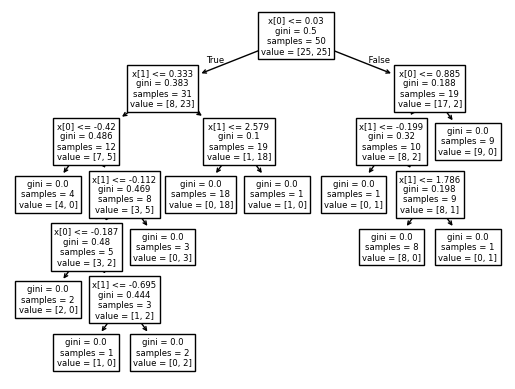

In [81]:
plot_tree(clf1)